# tap.autowah~ — Snow White validation harness

`tap.autowah~` models the **Mad Professor Snow White AutoWah**: a resonant 2-pole
filter swept up from the `bias` resting frequency by an envelope follower — fast
attack, `decay`-controlled release, `sensitivity` at the floor turning it into the
pedal's fixed "cocked wah". The full design and hardware research live in
TapTools-Max `plans/tap.autowah~.md`; this notebook is the **validation vehicle from
its §6**: it verifies the kernel's control behavior, and builds the *peak-trajectory
extractor* that will be pointed at recordings of the real pedal when it arrives.

The four numbers that define the feel (plan §6.2): **resting frequency**, **sweep
ceiling vs input level**, **attack time**, and the **decay curve shape** — plus Q.
Everything below runs the actual C++ kernel (`include/taptools/autowah.h`) through
the C ABI, reading the per-sample envelope/cutoff trajectories the ABI exposes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def spectrum_db(y, sr=fs):
    """Hann-windowed magnitude spectrum in dBFS-ish units."""
    n = len(y)
    w = np.hanning(n)
    Y = np.abs(np.fft.rfft(y * w)) / (np.sum(w) / 2)
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(Y + 1e-12)


def db_at(freqs, db, hz):
    return float(np.interp(hz, freqs, db))


def peak_freq(y, sr=fs, fmin=20.0):
    """Dominant frequency via parabolic interpolation on the windowed FFT peak."""
    freqs, db = spectrum_db(y, sr)
    sel = freqs >= fmin
    i = np.argmax(db[sel]) + np.searchsorted(freqs, fmin)
    if 0 < i < len(db) - 1:
        a, b, c = db[i - 1], db[i], db[i + 1]
        d = 0.5 * (a - c) / (a - 2 * b + c + 1e-30)
    else:
        d = 0.0
    return float((i + d) * sr / len(y))


rng = np.random.default_rng(3)


def funk_chops(seconds, rate_hz=4.0, amp=0.8):
    """Plucky noise bursts with sharp attack and exponential decay — staccato playing."""
    n = int(seconds * fs)
    sig = np.zeros(n)
    period = int(fs / rate_hz)
    idx = np.arange(n)
    ph = idx % period
    gate = ph < period // 3
    env = np.exp(-8.0 * ph / (fs * 0.1))
    sig[gate] = rng.standard_normal(gate.sum()) * amp * env[gate]
    return sig


def track_peak(y, sr=fs, nfft=2048, hop=256, fmin=100.0, fmax=6000.0):
    """STFT spectral-peak tracker: per-frame resonant-peak frequency + level.

    This is the tool from plan §6.2 — it needs only the *wet* audio, so the same
    code runs on hardware recordings and demo videos, no dry reference required."""
    win = np.hanning(nfft)
    freqs = np.fft.rfftfreq(nfft, 1 / sr)
    lo, hi = np.searchsorted(freqs, [fmin, fmax])
    times, peaks, levels = [], [], []
    for start in range(0, len(y) - nfft, hop):
        mag = np.abs(np.fft.rfft(y[start:start + nfft] * win))
        i = int(np.argmax(mag[lo:hi])) + lo
        if 0 < i < len(mag) - 1:
            a, b, c = np.log(mag[i - 1] + 1e-30), np.log(mag[i] + 1e-30), np.log(mag[i + 1] + 1e-30)
            d = 0.5 * (a - c) / (a - 2 * b + c + 1e-30)
        else:
            d = 0.0
        times.append((start + nfft / 2) / sr)
        peaks.append((i + d) * sr / nfft)
        levels.append(20 * np.log10(mag[i] / (np.sum(win) / 2) + 1e-12))
    return np.array(times), np.array(peaks), np.array(levels)


## 1. The sweep law — measured against the design curve

The model's law is `cutoff = bias · 2^(tanh(1.5·env) · range)`. We drive the
detector with settled DC key levels and read the cutoff back through the C ABI —
the measured curve must sit exactly on the design curve. The plot also shows the
**linear-in-Hz alternative** from the plan's open question §7.6: when the real
pedal is measured, this same plot decides which law the hardware follows —
`map_cutoff()` is one function either way.

measured vs design curve: max |error| = 0.000 cents


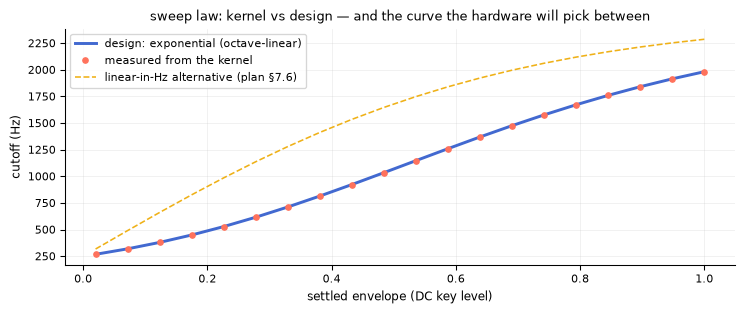

In [2]:
levels = np.linspace(0.02, 1.0, 20)
measured = []
for lv in levels:
    w = tap.Wah(fs)
    _, _, cut = w.process(np.zeros(fs), key=np.full(fs, lv), trace=True)
    measured.append(cut[-1])
measured = np.array(measured)

design = 250.0 * 2 ** (np.tanh(1.5 * levels) * 3.3)
cents = 1200 * np.log2(measured / design)
print(f"measured vs design curve: max |error| = {np.abs(cents).max():.3f} cents")
assert np.abs(cents).max() < 1.0

linear_alt = 250.0 + (2500.0 - 250.0) * np.tanh(1.5 * levels)   # the §7.6 alternative
fig, ax = plt.subplots()
ax.plot(levels, design, color=PAL[0], lw=2.2, label="design: exponential (octave-linear)")
ax.plot(levels, measured, "o", color=PAL[2], ms=4, label="measured from the kernel")
ax.plot(levels, linear_alt, color=PAL[1], lw=1.2, ls="--",
        label="linear-in-Hz alternative (plan §7.6)")
ax.set(xlabel="settled envelope (DC key level)", ylabel="cutoff (Hz)",
       title="sweep law: kernel vs design — and the curve the hardware will pick between")
ax.legend()
plt.show()

## 2. Attack and decay trajectories

A step key charges the follower with the attack constant; releasing it decays at
the `decay` rate — and the fall must be a clean exponential (the hardware is an RC
discharge). We keep the key small so the tanh knee is essentially linear, measure
both time constants from the envelope trajectory, and fit the release in log domain.

attack: 63% in 1.94 ms (set 2.0)  |  decay: to 36.8% in 256 ms (set 250)
log-domain release fit: tau = 252 ms, residual sigma = 0.004 (a pure exponential fits with ~0)


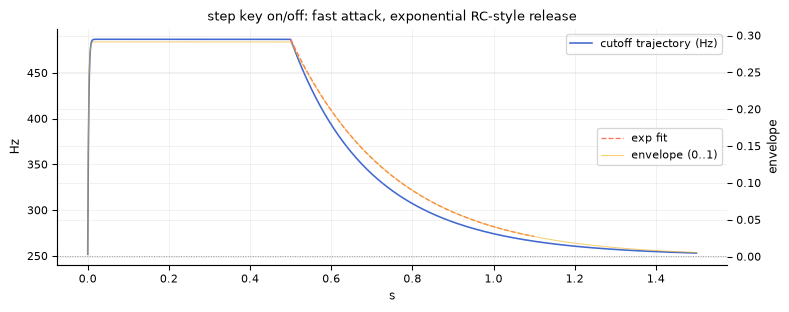

In [3]:
w = tap.Wah(fs, attack=2.0, decay=250.0)
key = np.concatenate([np.full(fs // 2, 0.2), np.zeros(fs)])
_, env, cut = w.process(np.zeros(len(key)), key=key, trace=True)

settled = env[fs // 2 - 100]
i_att = int(np.searchsorted(env[:fs // 2], settled * 0.632))
att_ms = 1000 * i_att / fs
rel = env[fs // 2:]
i_dec = int(np.searchsorted(-rel, -settled * 0.368))
dec_ms = 1000 * i_dec / fs

seg = rel[:int(0.6 * fs)]
tt = np.arange(len(seg)) / fs
mask = seg > settled * 0.02
slope, intercept = np.polyfit(tt[mask], np.log(seg[mask]), 1)
fit = np.exp(intercept + slope * tt)
resid = np.std(np.log(seg[mask]) - (intercept + slope * tt[mask]))
tau_fit_ms = -1000 / slope

print(f"attack: 63% in {att_ms:.2f} ms (set 2.0)  |  decay: to 36.8% in {dec_ms:.0f} ms (set 250)")
print(f"log-domain release fit: tau = {tau_fit_ms:.0f} ms, residual sigma = {resid:.3f} "
      f"(a pure exponential fits with ~0)")
assert abs(att_ms - 2.0) < 1.0
assert abs(dec_ms - 250) < 40
assert resid < 0.05

fig, ax = plt.subplots()
t = np.arange(len(key)) / fs
ax.plot(t, cut, color=PAL[0], lw=1.2, label="cutoff trajectory (Hz)")
ax.axhline(250, color="0.6", lw=0.7, ls=":")
ax.set(xlabel="s", ylabel="Hz", title="step key on/off: fast attack, exponential RC-style release")
ax2 = ax.twinx()
ax2.plot(t[fs // 2:fs // 2 + len(seg)], fit, color=PAL[2], lw=1.0, ls="--", label="exp fit")
ax2.plot(t, env, color=PAL[1], lw=0.8, alpha=0.6, label="envelope (0..1)")
ax2.set_ylabel("envelope")
ax.legend(loc="upper right")
ax2.legend(loc="center right")
plt.show()

## 3. The peak-trajectory extractor recovers the sweep from wet audio alone

This is the §6.2 workhorse: an STFT peak tracker that recovers the swept resonant
peak from a **wet-only recording** — the same measurement that will be run on the
official demo videos and on the real pedal. We prove the tool on ground truth:
sustained noise with slow tremolo-like dynamics keeps the filter continuously
excited while the level swings it up and down; the extracted peak trajectory must
correlate with the kernel's actual cutoff trace from the C ABI. (Staccato material
works for listening, but between plucks there is nothing to track — sustained
excitation is the right *measurement* stimulus, which is exactly why the plan's
reamp recipe pairs playing material with sweeps.) The small constant offset is
physics: a resonant lowpass peaks slightly below its nominal cutoff, at
fc·√(1−1/2Q²).

voiced frames: 746/746; log-frequency correlation = 0.979
median offset -37 cents (resonant-peak physics predicts -20 cents at this Q)


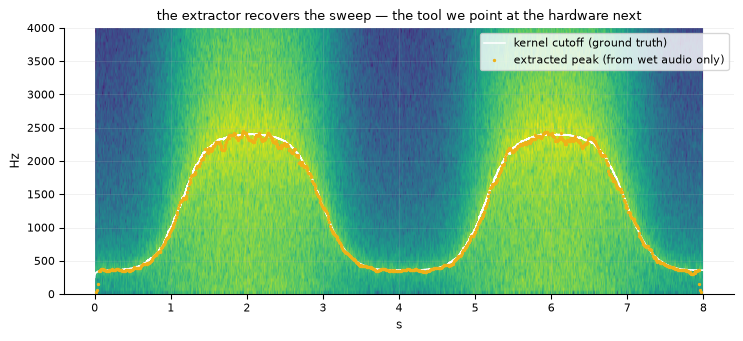

In [4]:
n = 8 * fs
t = np.arange(n) / fs
swell = 0.05 + 0.75 * (0.5 - 0.5 * np.cos(2 * np.pi * 0.25 * t)) ** 2   # slow 0.25 Hz surges
bed = rng.standard_normal(n) * swell
w = tap.Wah(fs, resonance=0.85, decay=250.0)
y, env, cut = w.process(bed, trace=True)

times, peaks, levels = track_peak(y, hop=512)
smooth = np.exp2(np.convolve(np.log2(peaks), np.ones(7) / 7, mode="same"))
cut_at = np.interp(times, np.arange(len(cut)) / fs, cut)
voiced = levels > (levels.max() - 45)
corr = np.corrcoef(np.log2(smooth[voiced]), np.log2(cut_at[voiced]))[0, 1]
offset_cents = np.median(1200 * np.log2(smooth[voiced] / cut_at[voiced]))
q = 0.70710678 / (1 - 0.85)                                   # svf resonance -> Q
predicted = 600 * np.log2(1 - 1 / (2 * q * q))                # peak-below-cutoff, in cents
print(f"voiced frames: {voiced.sum()}/{len(voiced)}; "
      f"log-frequency correlation = {corr:.3f}")
print(f"median offset {offset_cents:+.0f} cents (resonant-peak physics predicts "
      f"{predicted:+.0f} cents at this Q)")
assert corr > 0.9

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.specgram(y, NFFT=1024, Fs=fs, noverlap=768, cmap="viridis", vmin=-140)
ax.plot(np.arange(len(cut)) / fs, cut, color="w", lw=1.2, label="kernel cutoff (ground truth)")
ax.plot(times[voiced], smooth[voiced], ".", color=PAL[1], ms=3,
        label="extracted peak (from wet audio only)")
ax.set(ylim=(0, 4000), xlabel="s", ylabel="Hz",
       title="the extractor recovers the sweep — the tool we point at the hardware next")
ax.legend(loc="upper right")
plt.show()

## 4. Factory voicings, side by side

Slots 0–3 ship the author-approved voicings: **guitar** (the hardware's home
position), **bass** (the GB switch as a preset — lower bias, tighter range),
**slow swell**, and **cocked wah** (sensitivity off ⇒ a fixed filter — its cutoff
trace must be perfectly flat at bias).

/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:8647: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


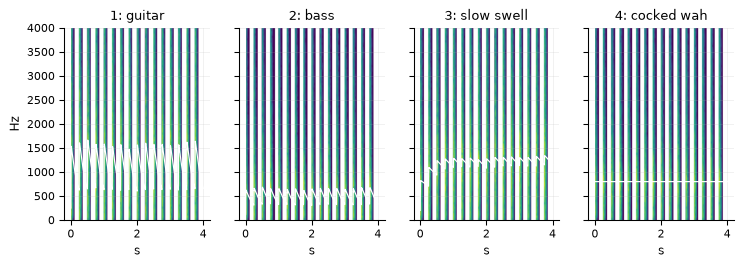

cutoff ceilings: {'guitar': '1664 Hz', 'bass': '683 Hz', 'slow swell': '1341 Hz', 'cocked wah': '800 Hz'}


In [5]:
chops = funk_chops(4.0)
names = ["guitar", "bass", "slow swell", "cocked wah"]
fig, axes = plt.subplots(1, 4, figsize=(9, 2.6), sharey=True)
ceilings = {}
for slot, (name, ax) in enumerate(zip(names, axes)):
    w = tap.Wah(fs).recall(slot)
    y, env, cut = w.process(chops, trace=True)
    ax.specgram(y, NFFT=1024, Fs=fs, noverlap=512, cmap="viridis", vmin=-140)
    ax.plot(np.arange(len(cut)) / fs, cut, color="w", lw=0.9)
    ax.set(ylim=(0, 4000), title=f"{slot + 1}: {name}", xlabel="s")
    ceilings[name] = cut.max()
axes[0].set_ylabel("Hz")
plt.show()

print("cutoff ceilings:", {k: f"{v:.0f} Hz" for k, v in ceilings.items()})
assert ceilings["cocked wah"] == 800.0 and ceilings["bass"] < ceilings["guitar"]
w = tap.Wah(fs).recall(3)
_, _, cut = w.process(chops, trace=True)
assert cut.std() == 0.0   # cocked: the envelope is off, the filter never moves

## 5. Rectifier A/B — the half-wave ripple, quantified

The traced hardware detector is a single diode (half-wave); the kernel defaults to
full-wave for cleaner tracking, with half-wave selectable for the calibration A/B
(plan §7.8). Half-wave rectification leaves signal-rate ripple on the envelope —
here it is, measured, so the listening A/B has a number attached.

settled envelope ripple (std/mean): {'full-wave': '0.7%', 'half-wave': '2.6%'}


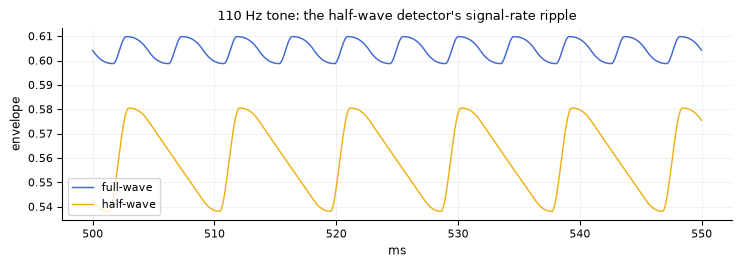

In [6]:
t = np.arange(fs) / fs
tone = 0.5 * np.sin(2 * np.pi * 110 * t)
ripple = {}
traces = {}
for name, rect in (("full-wave", tap.Wah.FULLWAVE), ("half-wave", tap.Wah.HALFWAVE)):
    w = tap.Wah(fs, decay=60.0)
    w.set(rectifier=rect)
    _, env, _ = w.process(tone, trace=True)
    seg = env[fs // 2:]
    ripple[name] = seg.std() / seg.mean()
    traces[name] = env
print("settled envelope ripple (std/mean):",
      {k: f"{v * 100:.1f}%" for k, v in ripple.items()})
assert ripple["half-wave"] > 2 * ripple["full-wave"]

fig, ax = plt.subplots(figsize=(9, 2.6))
zoom = slice(fs // 2, fs // 2 + int(0.05 * fs))
for i, (name, env) in enumerate(traces.items()):
    ax.plot(np.arange(zoom.start, zoom.stop) / fs * 1000, env[zoom], color=PAL[i],
            lw=1.1, label=name)
ax.set(xlabel="ms", ylabel="envelope", title="110 Hz tone: the half-wave detector's signal-rate ripple")
ax.legend()
plt.show()

## 6. Pointing this at the real pedal

When the Snow White arrives (it's on order — plan §6.3), the calibration pass is:

1. **Reamp a known stimulus** through the pedal at documented knob positions — the
   NAM standardized DI (`v3_0_0.wav`), IDMT slap-bass notes, or simply the funk-chop
   WAVs from `autowah_render` — and record the wet output.
2. Drop the recordings in `notebooks/reference/` as
   `snowwhite_<desc>.wav` next to the *same* dry stimulus rendered through the model
   (`autowah_render --in dry.wav <slot>`).
3. Run the cell below: it extracts both peak trajectories with `track_peak` and
   overlays them. Matching the four numbers (resting Hz, ceiling, attack, decay
   shape) — and the offset/Q — *is* the calibration; disagreements map one-to-one
   onto kernel constants (`k_env_knee`, attack/decay defaults, `map_cutoff()`'s law,
   the default tap and `resonance`).

The cell is a no-op until reference files exist, so the notebook always executes.

In [7]:
import pathlib
import wave


def read_wav_mono(path):
    """Minimal WAV reader (PCM16 + float32), channel 0."""
    with open(path, "rb") as fh:
        raw = fh.read()
    with wave.open(str(path), "rb") as wf:
        nch, sw, sr = wf.getnchannels(), wf.getsampwidth(), wf.getframerate()
        frames = wf.readframes(wf.getnframes())
    if sw == 2:
        y = np.frombuffer(frames, "<i2").astype(np.float64) / 32768.0
    elif sw == 4:
        y = np.frombuffer(frames, "<f4").astype(np.float64)
    else:
        raise ValueError(f"unsupported sample width {sw}")
    return y[::nch], sr


REF = pathlib.Path(tap.KERNEL) / "notebooks" / "reference"
pairs = sorted(REF.glob("snowwhite_*.wav")) if REF.exists() else []
if not pairs:
    print("no hardware recordings yet - drop snowwhite_*.wav (and matching model_*.wav)")
    print(f"into {REF} and re-run. See plan section 6.3 for the reamp recipe.")
else:
    fig, ax = plt.subplots()
    for i, p in enumerate(pairs):
        y, sr = read_wav_mono(p)
        times, peaks, levels = track_peak(y, sr)
        voiced = levels > (levels.max() - 35)
        ax.plot(times[voiced], peaks[voiced], ".", ms=3, color=PAL[i % len(PAL)], label=p.stem)
        model = p.with_name(p.name.replace("snowwhite_", "model_"))
        if model.exists():
            ym, srm = read_wav_mono(model)
            tm, pm, lm = track_peak(ym, srm)
            vm = lm > (lm.max() - 35)
            ax.plot(tm[vm], pm[vm], "-", lw=0.9, color=PAL[i % len(PAL)], alpha=0.6)
    ax.set(xlabel="s", ylabel="Hz", yscale="log",
           title="hardware (dots) vs model (lines) - peak trajectories")
    ax.legend()
    plt.show()

print("\ntap.autowah~ validation harness complete - kernel claims verified,")
print("extractor proven on ground truth, hardware comparison ready and waiting.")

no hardware recordings yet - drop snowwhite_*.wav (and matching model_*.wav)
into /home/user/TapTools/notebooks/reference and re-run. See plan section 6.3 for the reamp recipe.

tap.autowah~ validation harness complete - kernel claims verified,
extractor proven on ground truth, hardware comparison ready and waiting.
